In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
data = pd.read_csv('ford_car_dataset - ford_car_dataset.csv')

print(" First 10 rows of the dataset:")
print(data.head(10))

print("\n Shape of the dataset:")
print(data.shape)

#The dataset contains information about various Ford car models, including their specifications and features. 
#The first 10 rows of the dataset provide a glimpse into the data, while the shape of the dataset indicates the number of rows and columns present.

 First 10 rows of the dataset:
    model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4  Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5  Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6    Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7  Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8    Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9   Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

 Shape of the dataset:
(17966, 9)


In [58]:
print("Missing values in the dataset:")
print(data.isnull().sum())

duplicate_rows = data.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {duplicate_rows}")
data = data.drop_duplicates()

# We find the duplicate rows in the dataset and remove them to ensure data integrity.
# This step is crucial for accurate analysis and modeling.
# we remove them with the drop_duplicates() function, which eliminates any duplicate entries based on all columns.

Missing values in the dataset:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Number of duplicate rows in the dataset: 154


In [59]:
print("Stastistical summary of the dataset:")
print(data.describe())

print("Price column:")
print("Maximum Value of price:",data["price"].max())
print("Minimum Value of price:",data["price"].min())
print("Average Value of price:",data["price"].mean())
print("median Value of price:",data["price"].median())
print("\n Mileage column:")
print("Maximum value of mileage:",data["mileage"].max())
print("Minimum value of mileage:",data["mileage"].min())
print("Average value of mileage:",data["mileage"].mean())
print("median value of mileage:",data["mileage"].median())

print("\n Year column:")
print("Maximum value of year:",data["year"].max())
print("Minimum value of year:",data["year"].min())
print("Average value of year:",data["year"].mean())
print("median value of year:",data["year"].median())

Stastistical summary of the dataset:
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
Price column:
Maximum Value of price: 54995


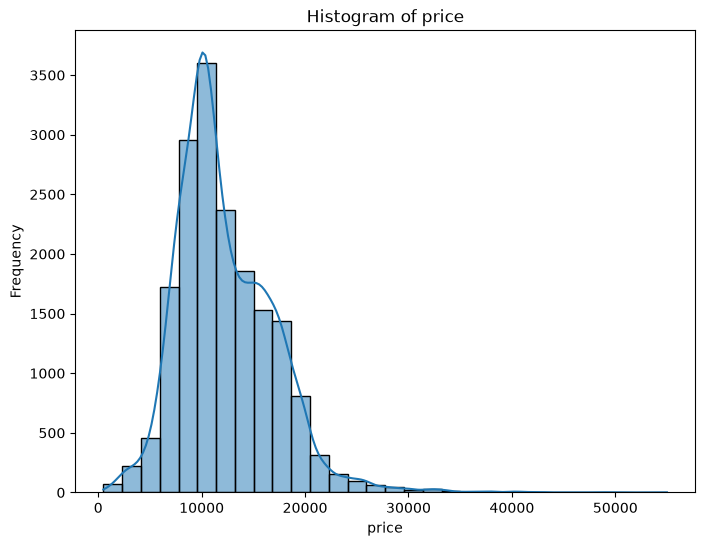

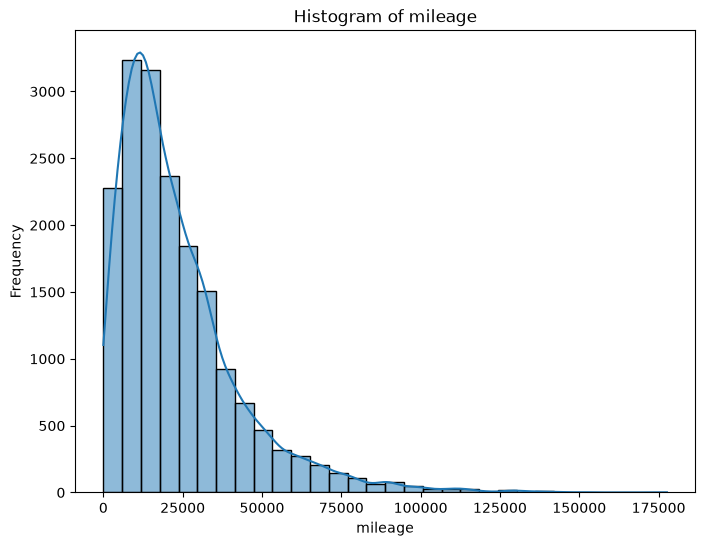

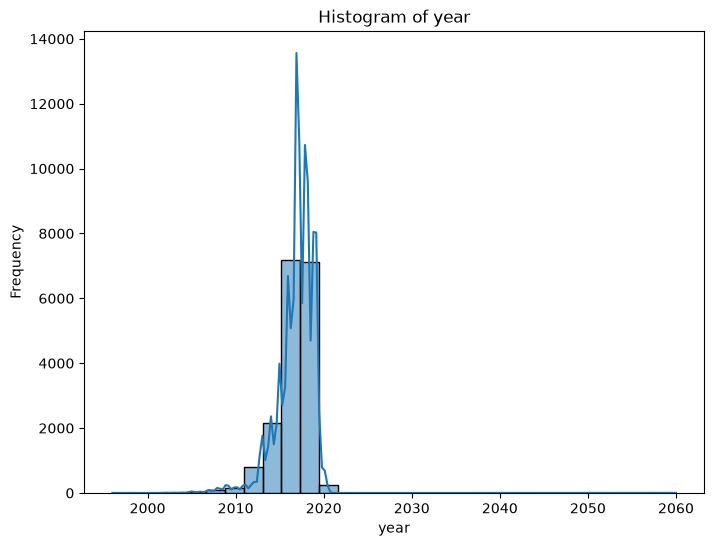

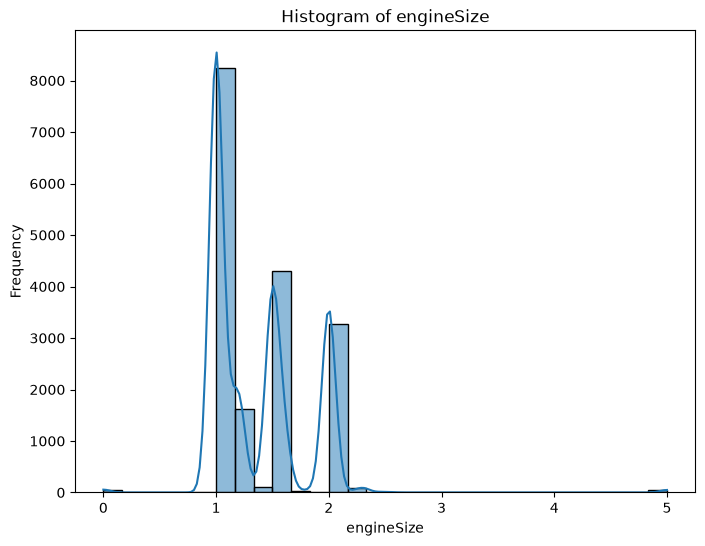

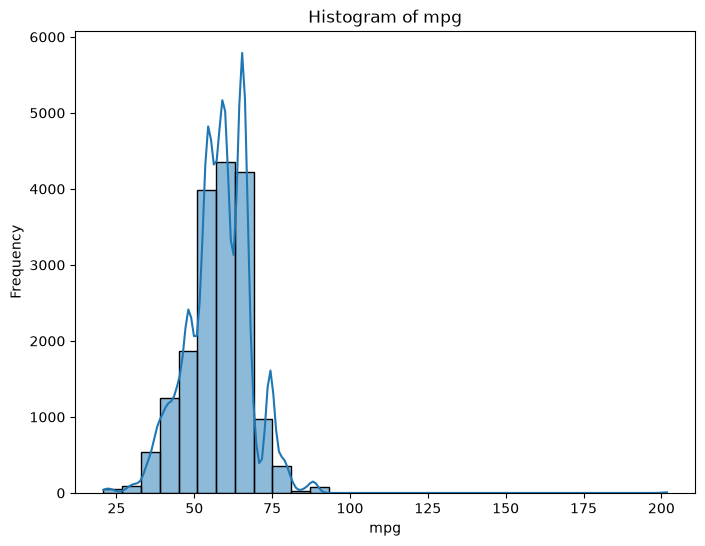

In [60]:
def plot_histograms(data):
    columns = ['price', 'mileage', 'year','engineSize','mpg']
    for column in columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data[column], bins=30, kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show() 
plot_histograms(data) 

# Findings:

# 1. Price:
# - Most cars are in the lower to medium price range.
# - A few expensive cars create a right-skewed distribution.

# 2. Mileage:
# - Most vehicles have low to medium mileage.
# - High-mileage cars are fewer, causing a right-skewed distribution.

# 3. Year:
# - Most cars are from recent years.
# - Older cars are less common.

# 4. Engine Size:
# - Most cars have engine sizes between 1.0L and 2.0L.
# - Larger engine sizes are relatively rare.

# 5. MPG (Miles Per Gallon):
# - Most cars have moderate to high fuel efficiency.
# - Very low or very high MPG values occur less frequently.

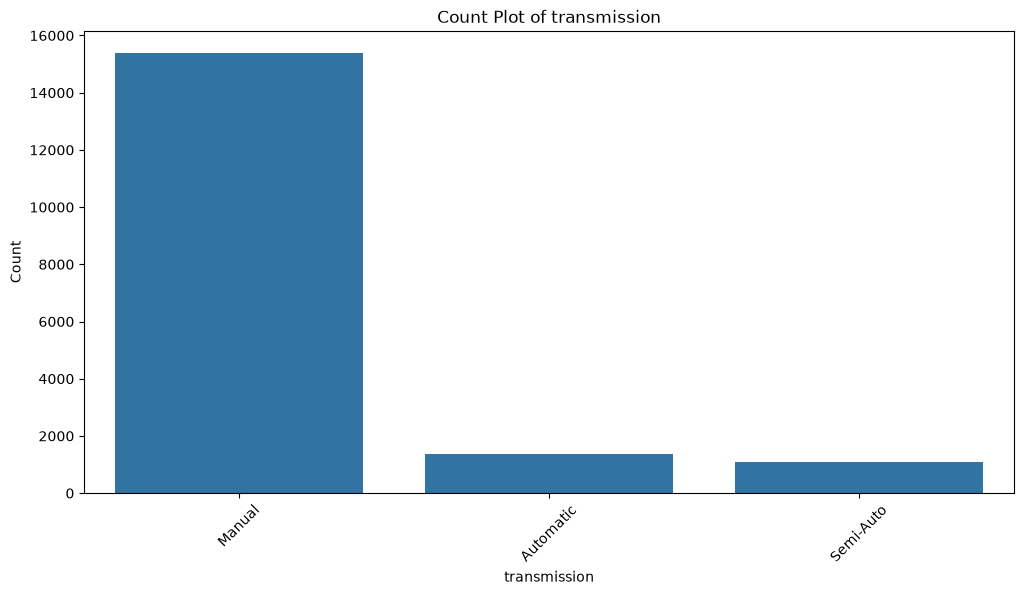

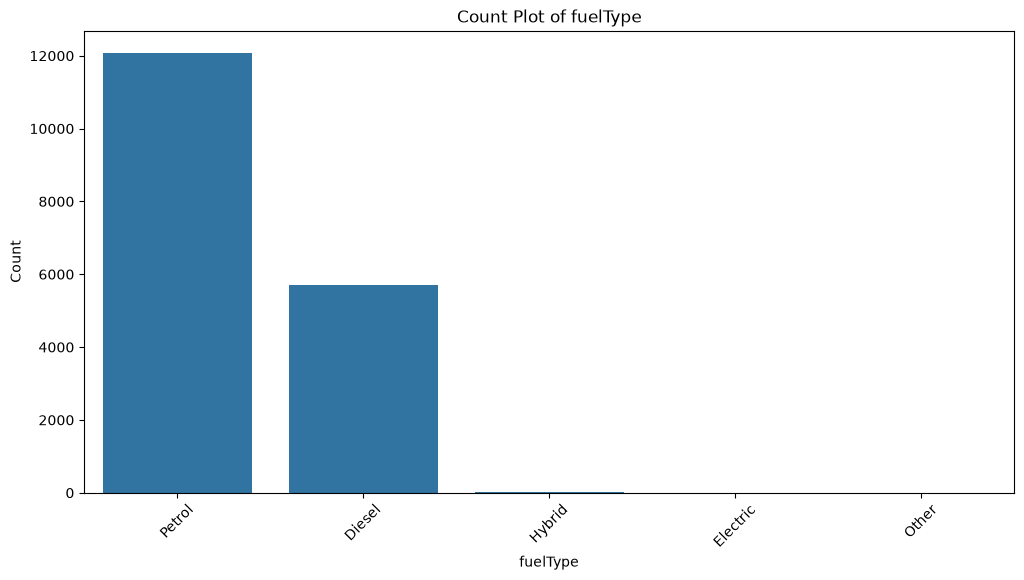

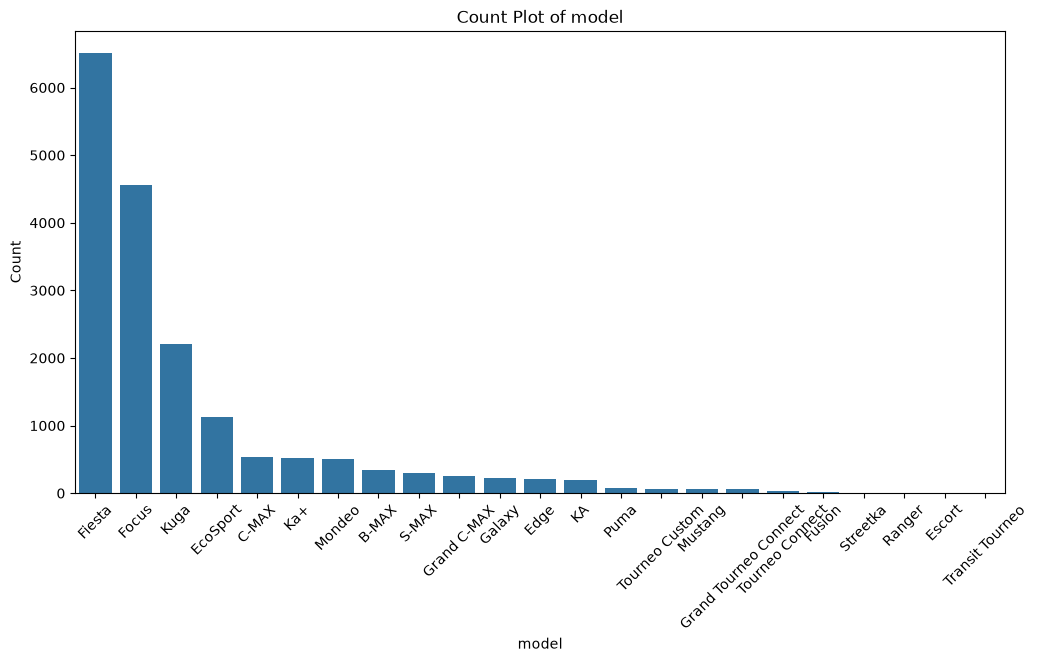

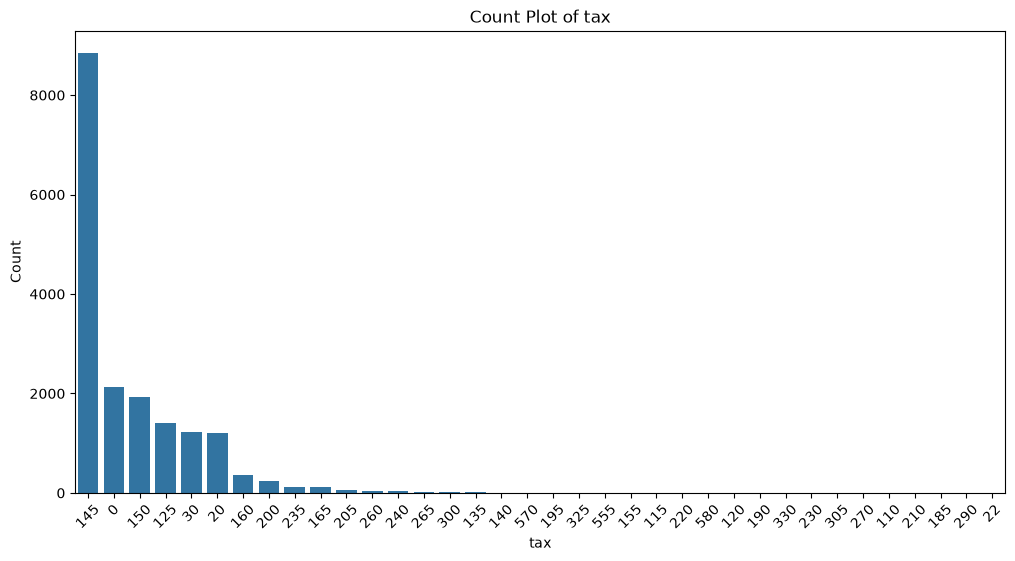

In [61]:
def plot_countplots(data):
    columns = ['transmission', 'fuelType', 'model', 'tax']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Findings:

# 1. Fuel Type:
# - Petrol is the most common fuel type.
# - Diesel is the second most common.
# - Hybrid and Electric cars are fewer.

# 2. Transmission:
# - Manual transmission cars are the most common.
# - Automatic cars are fewer.

# 3. Model:
# - A few Ford models have a very high number of listings.
# - Some models appear only a few times, indicating lower availability.

# 4. Tax:
# - Most cars have a relatively low tax rate.
# - A small number of cars have higher tax rates.

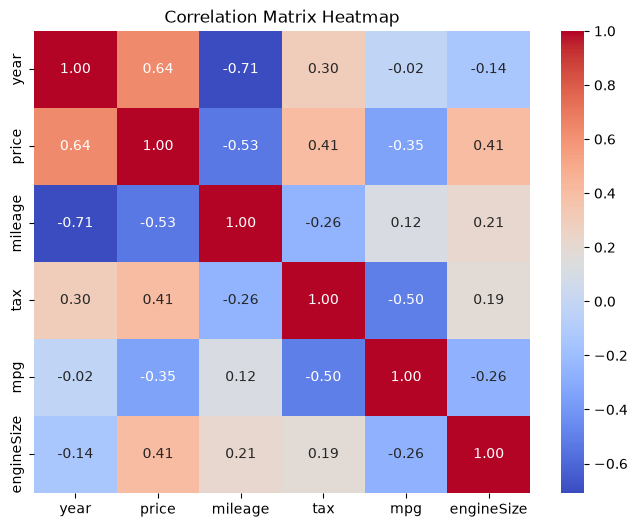

Correlation with Price:
price         1.000000
year          0.635715
engineSize    0.411451
tax           0.405969
mpg          -0.346263
mileage      -0.530483
Name: price, dtype: float64


In [62]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Title
plt.title("Correlation Matrix Heatmap")

# Show plot
plt.show()

# Display correlation with price
print("Correlation with Price:")
print(corr_matrix["price"].sort_values(ascending=False))

# Observations:

# 1. Price has a strong positive correlation with Year.
#    -> Newer cars generally have higher prices.

# 2. Price has a positive correlation with Engine Size.
#    -> Cars with larger engines tend to be more expensive.

# 3. Price has a negative correlation with Mileage.
#    -> As mileage increases, the price generally decreases.

# 4. MPG shows a weak or moderate correlation with Price.
#    -> Fuel efficiency has less impact on price than year or mileage.

# 5. Year and Mileage are negatively correlated.
#    -> Newer cars usually have lower mileage.

# 6. The features most strongly related to the target variable (Price)
#    are Year, Engine Size, and Mileage.


In [65]:
# Independent Features (X)
X = data[['model', 'year', 'transmission', 'mileage',
        'fuelType', 'tax', 'mpg', 'engineSize']]

# Dependent Feature (y)
y = data['price']

# Reasoning:

# Independent Features:
# These columns describe the characteristics of each car,
# such as model, manufacturing year, mileage, fuel type,
# engine size, transmission, tax, and fuel efficiency (mpg).
# They are used as input variables to predict the car price.

# Dependent Feature:
# 'price' is the target variable because it is the value
# that the machine learning model aims to predict based on
# the input features.

In [73]:
print("Categorical Features Before Encoding:")
print(data[['model', 'transmission', 'fuelType']].head())

encoded_features = pd.get_dummies(data[['model', 'transmission', 'fuelType']])
print("\nCategorical Features After Encoding:")
print(encoded_features.head())

Categorical Features Before Encoding:
    model transmission fuelType
0  Fiesta    Automatic   Petrol
1   Focus       Manual   Petrol
2   Focus       Manual   Petrol
3  Fiesta       Manual   Petrol
4  Fiesta    Automatic   Petrol

Categorical Features After Encoding:
   model_B-MAX  model_C-MAX  model_EcoSport  model_Edge  model_Escort  \
0        False        False           False       False         False   
1        False        False           False       False         False   
2        False        False           False       False         False   
3        False        False           False       False         False   
4        False        False           False       False         False   

   model_Fiesta  model_Focus  model_Fusion  model_Galaxy  model_Grand C-MAX  \
0          True        False         False         False              False   
1         False         True         False         False              False   
2         False         True         False         False

In [79]:
from sklearn.preprocessing import StandardScaler
# Select numeric independent features
X = data[['year', 'mileage', 'tax', 'mpg', 'engineSize']]

# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("First 5 rows of Scaled Data:")
print(X_scaled.head())


First 5 rows of Scaled Data:
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


    model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4  Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows: 0


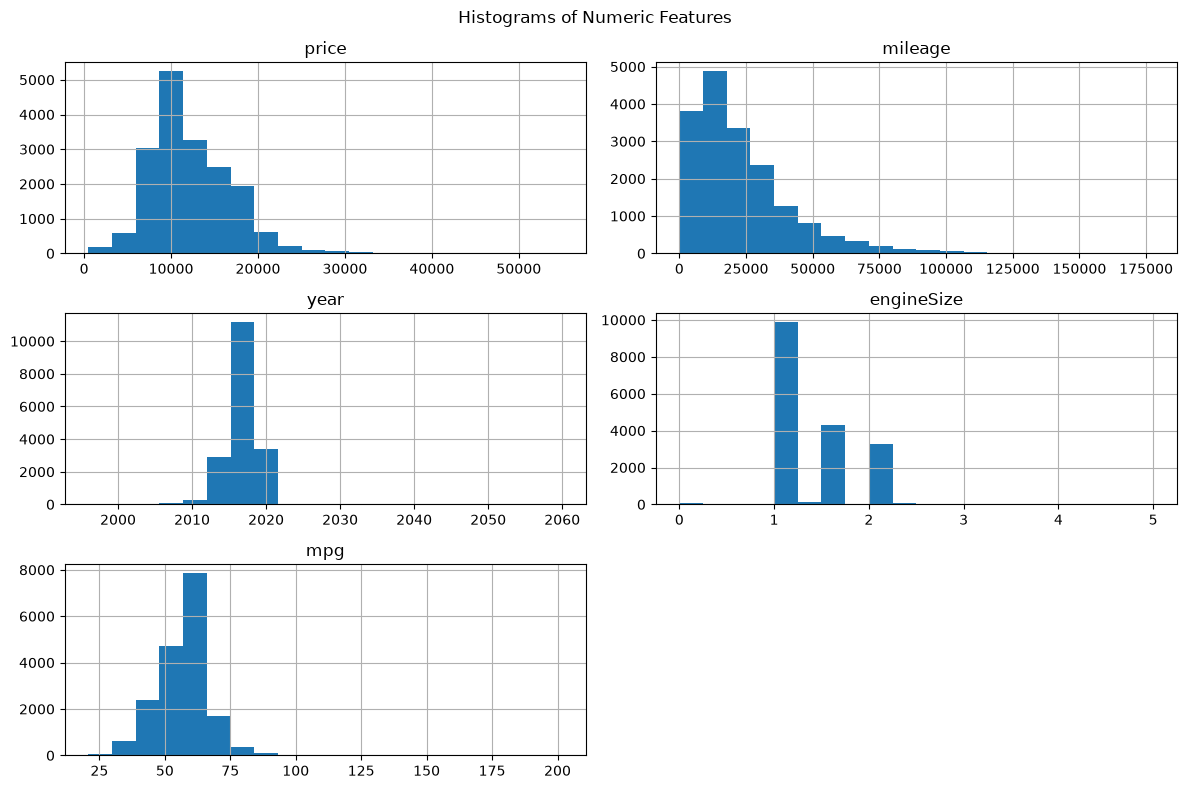

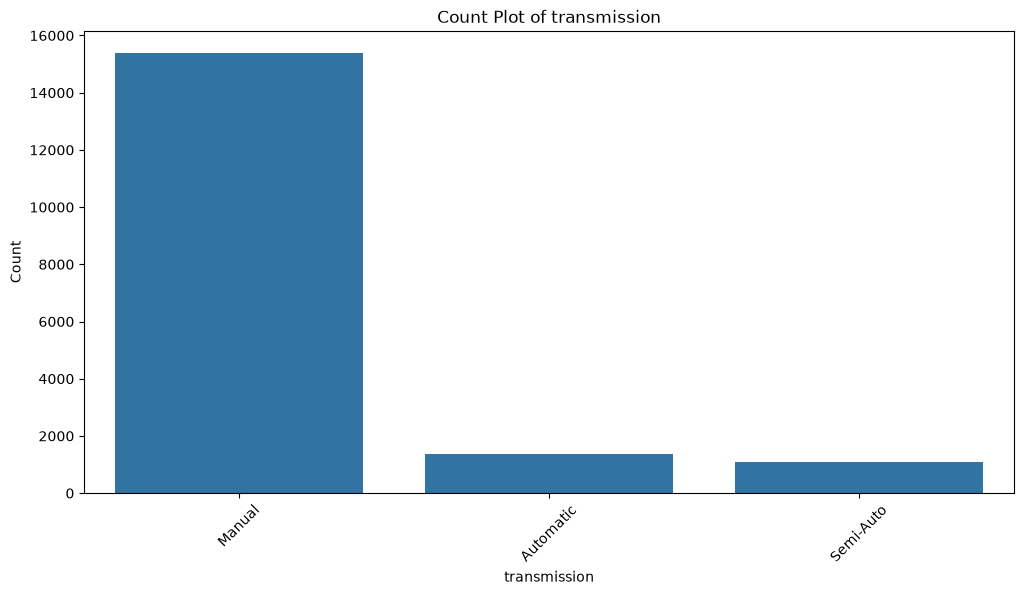

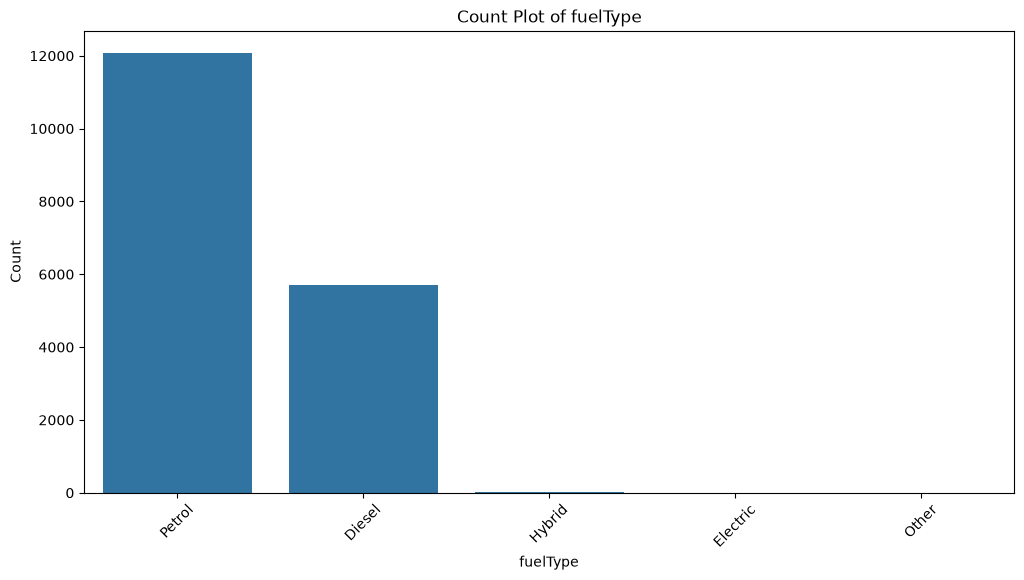

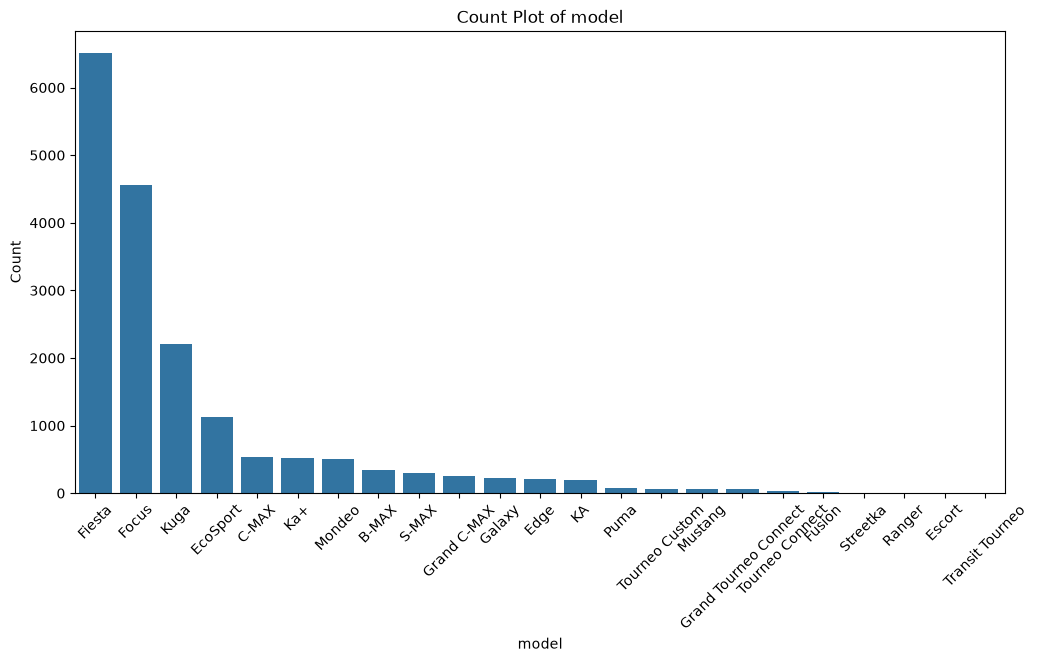

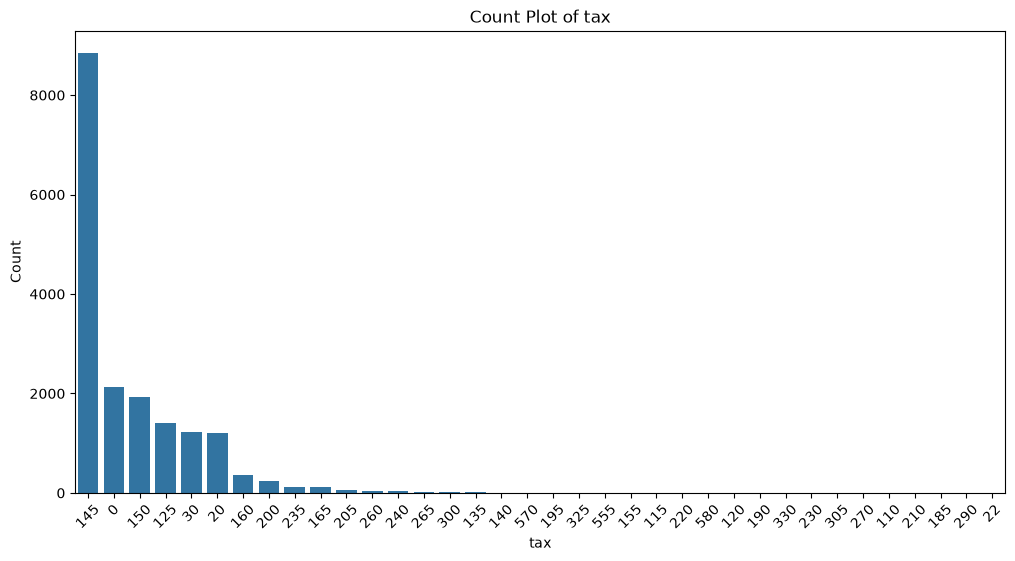

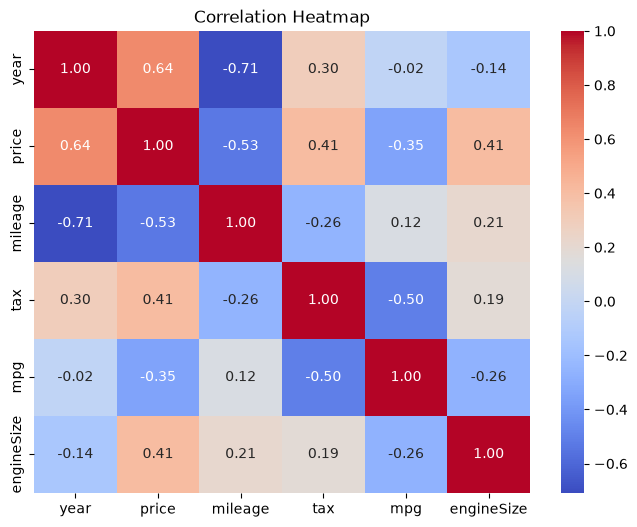


Independent Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

Dependent Feature:
price

Encoded Data:
   year  mileage  tax   mpg  engineSize  model_C-MAX  model_EcoSport  \
0  2017    15944  150  57.7         1.0        False           False   
1  2018     9083  150  57.7         1.0        False           False   
2  2017    12456  150  57.7         1.0        False           False   
3  2019    10460  145  40.3         1.5        False           False   
4  2019     1482  145  48.7         1.0        False           False   

   model_Edge  model_Escort  model_Fiesta  ...  model_Streetka  \
0       False         False          True  ...           False   
1       False         False         False  ...           False   
2       False         False         False  ...           False   
3       False         False          True  ...           False   
4       False         False          True  ...         

In [84]:
# Display first 5 rows
print(data.head())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values
data.dropna(inplace=True)

# Check duplicate values
print("\nDuplicate Rows:", data.duplicated().sum())

# Remove duplicates
data.drop_duplicates(inplace=True)

# --------------------------
# 2. Exploratory Data Analysis (EDA)
# --------------------------

# Histogram of Numeric Features
numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']

data[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

# Count Plots for Categorical Features
def plot_countplots(data):
    columns = ['transmission', 'fuelType', 'model', 'tax']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Correlation Heatmap
plt.figure(figsize=(8,6))

corr = data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# 3. Input and Output Features
# --------------------------

X = data.drop("price", axis=1)
y = data["price"]

print("\nIndependent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

# --------------------------
# 4. Encode Categorical Variables
# --------------------------

X = pd.get_dummies(
    X,
    columns=['model', 'transmission', 'fuelType'],
    drop_first=True
)

print("\nEncoded Data:")
print(X.head())

# --------------------------
# 5. Scale Numeric Features
# --------------------------

scaler = StandardScaler()

numeric_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFirst 5 Rows of Scaled Data:")
print(X.head())

# --------------------------
# Project Completed
# --------------------------
print("\nPreprocessing Pipeline Completed Successfully!")